In [107]:
import sys
print(sys.executable)

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from arch import arch_model
from scipy.stats import norm
from Calvet_MSM_Gab import *


/opt/anaconda3/bin/python


In [139]:
# Step 1: Load the CSV data
print("Loading the data from CSV...")
df = pd.read_csv("BTC-USD.csv", parse_dates=["Date"], index_col="Date")
start_date = '2024-01-01'
end_date = '2024-12-31'

# Convert to datetime
end_date = pd.to_datetime(end_date)
start_date = pd.to_datetime(start_date)
df_train = df.loc[start_date:end_date - pd.Timedelta(days=15)]
debut_prediction_date = df.loc["2025-01-01", " Price"]
df = df.loc[start_date:end_date] # Filter data between start_date and end_date
df.columns = df.columns.str.strip()  # Remove leading/trailing whitespaces from column names
df_train.columns = df_train.columns.str.strip()
print("Data loaded and filtered between dates:", start_date, "and", end_date)

# Step 2: Calculate the daily log returns
print("Calculating the daily log returns...")
df['Log_Ret'] = np.log(df['Price'] / df['Price'].shift(1))
df_train['Log_Ret'] = np.log(df_train['Price'] / df_train['Price'].shift(1))
print("Log returns calculated.")

Loading the data from CSV...
Data loaded and filtered between dates: 2024-01-01 00:00:00 and 2024-12-31 00:00:00
Calculating the daily log returns...
Log returns calculated.


In [140]:
# parameters MSM
print("Step 6: Estimating parameters for the MSM...")
niter = 1
temperature = 1.0
stepsize = 1.0
k_bar = 4
data = df_train['Log_Ret'].values[:, np.newaxis]
data = data[1:]
#print(data)
parameters, LL, niter, output = glo_min(k_bar, data, niter, temperature, stepsize)
print(LL)
# name parameters for later use:
b = parameters[0]
m_0 = parameters[1]
gamma_kbar = parameters[2]
sigma = parameters[3]

pi_t = g_pi_t(m_0,k_bar,data,[b, gamma_kbar, sigma])[-1,:]
A = g_t(k_bar, b, gamma_kbar)

print("Parameters from glo_min for Simulated dataset: ", "\n"
      "kbar = ", k_bar,"\n"
      'b = %.5f' % b,"\n"
      'm_0 = %.5f' % m_0,"\n"
      'gamma_kbar = %.5f' % gamma_kbar,"\n"
      'sigma = %.5f' % sigma,"\n")

Step 6: Estimating parameters for the MSM...
-776.1551470018114
Parameters from glo_min for Simulated dataset:  
kbar =  4 
b = 1.49888 
m_0 = 1.43139 
gamma_kbar = 0.96490 
sigma = 0.02784 



In [143]:
def compute_state_vols(m0, k_bar, sigma):
        m1 = 2-m0
        """Computes the volatility values for each of the 2**k_bar states in the MSM."""
        states = np.array([m0**(k_bar - np.sum(np.array(list(np.binary_repr(i, width=k_bar)), dtype=int))) *
                        m1**(np.sum(np.array(list(np.binary_repr(i, width=k_bar)), dtype=int)))
                        for i in range(2**k_bar)])
        states = sigma*np.sqrt(states)
        return states

def msm_volatilite_instantanee(pi_t, m0, k_bar, sigma):
        """retourne un array de taille pi_t"""
        state_vols = compute_state_vols(m0, k_bar, sigma)
        return np.sqrt(np.dot(pi_t, state_vols**2))


def simulate_paths(simulations, price):
    "transforme log return en prix"
    N, T = simulations.shape
    simulations_path = np.zeros((N, T + 1))  # Include initial price in paths

    for i in range(N):  # Iterate over simulations
        logret = simulations[i, :]  # Select row i
        path = np.zeros(T + 1)
        path[0] = price  # Set initial price
        for t in range(1, T + 1):  # Start from 1
            path[t] = path[t - 1] * np.exp(logret[t - 1])  # Apply geometric return formula
        simulations_path[i, :] = path  # Store full path
    # print("path")
    # print(simulations_path[:, 1])  # Second column, first step after initial price
    return simulations_path

def monte_carlo_markov(N, T, A, pi_t, m0, k_bar, sigma):
    variance_vect = compute_state_vols(m0, k_bar, sigma)
    #simuler msm à partir de pi_t
    num_states = len(pi_t)
    simulations = np.zeros((N, T))  
    sigma_array = np.zeros((N, T)) 
    stationary_dist = np.linalg.matrix_power(A, 1000)[0]
    for i in range(N):
        state = np.random.choice(num_states, p=pi_t)  # Start from initial distribution

        for t in range(T):
            sigma = variance_vect[state]
            simulations[i, t] = np.random.normal(scale = sigma)
            sigma_array[i, t] = sigma
            state = np.random.choice(num_states, p=A[state, :])
    # print("simu")
    # print(simulations)
    return(simulations, sigma_array)




N = 10000
T = 30
simulation_lr,volatilite_mat = monte_carlo_markov(N,T+1,A,pi_t,m_0,k_bar,sigma)
price = debut_prediction_date
simulation_p = simulate_paths(simulation_lr,price)
simulation_vol = np.std(simulation_lr, axis = 0)
volatilite_arr = np.mean(volatilite_mat, axis = 0)
print(simulation_vol) 
for i in range(len(simulation_p[0])):
     print(simulation_p[0][i])

#diff = simulation_vol - volatilite_arr
#print("Décalage moyen :", np.mean(diff))

[0.02575671 0.0274078  0.02758879 0.02781667 0.02785034 0.02866813
 0.02869235 0.02749912 0.02797473 0.02764502 0.02778674 0.02773862
 0.02775234 0.02779587 0.02783779 0.02741624 0.02759387 0.02741737
 0.02733745 0.02788463 0.02751901 0.02787669 0.0274078  0.02831444
 0.02739239 0.02810956 0.02780371 0.02751037 0.02778381 0.02771848
 0.02759398]
94419.76
95818.59878039989
96276.38017324229
98307.37740582017
98921.46796804221
99186.80820833005
100501.05951567751
100148.65774912195
101245.3352308489
105961.02085884214
106507.839721233
104577.7314703005
100230.3414058675
98935.85626230558
98907.34578523523
100310.68258000918
98683.00661149873
93196.1874383309
95032.31416394291
95376.0716977074
94680.0729660399
108383.69244728373
114573.7979992311
113209.16861718736
115250.33364382086
114079.53746577393
102224.62647032335
98743.79098177623
100246.65479451096
95421.16499645222
95446.96838935085
94757.96707391029


In [111]:
from tabulate import tabulate

def display_sample_logreturns(log_returns, num_paths=25, filename="logreturns_sample.pdf"):
    """
    log_returns : ndarray (N x T), N traj., T jours
    num_paths : nombre de trajectoires à afficher (max ~30 conseillé)
    """
    N, T = log_returns.shape
    if num_paths > N:
        raise ValueError("num_paths > N")
    
    # Sélection aléatoire des trajectoires
    indices = np.random.choice(N, size=num_paths, replace=False)
    selected = log_returns[indices, :]

    jours_selectionnes = [0, 1, 2, T//2 - 1, T//2, T//2 + 1, T-3, T-2, T-1]
    selected_days = np.array(jours_selectionnes)
    
    fig, ax = plt.subplots(figsize=(T * 0.25, num_paths * 0.4))
    
    # Création tableau de texte
    table_data = [[f"{selected[i, j]:.3f}" for j in selected_days] for i in range(num_paths)]
    table = ax.table(cellText=table_data,
                     colLabels=[f"J{j+1}" for j in selected_days],
                     loc='center', cellLoc='center')
    
    table.scale(0.3, 3)

    ax.axis('off')
    

    # Appliquer un style plus doux (gris clair sur fond blanc)
    for key, cell in table.get_celld().items():
        cell.set_linewidth(0)  # Supprime les lignes
        cell.set_edgecolor('white')  # Pas de bordures
        if key[0] == 0:  # Ligne des labels
            cell.get_text().set_weight('bold')
            cell.set_facecolor("#f5f5f5")  # Gris très clair pour l'entête
        else:
            cell.set_facecolor('#eaeaea' if key[0] % 2 == 0 else 'white')  # Effet zébré

    # Ajouter une "suggestion visuelle" de séparation : petits points entre colonnes
    for col in range(1, len(selected_days)):
        ax.axvline(x=col / len(selected_days), color='gray', linestyle=':', linewidth=0.5, alpha=0.5)

    plt.tight_layout()
    plt.savefig(filename, format='pdf')
    plt.show()

# Exemple d'utilisation
# Simuler un tableau (à remplacer par ta vraie simulation MSM)  # nombre de jours
simulated_log_returns = simulation_lr


# Affichage intelligent
#display_sample_logreturns(simulated_log_returns, num_paths=25)
latex_table = tabulate(simulated_log_returns, tablefmt="latex_booktabs")


In [112]:
import pandas as pd
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

# --- PARAMÈTRES À DÉFINIR ---
csv_path = "BTC-USD.csv"
date_col = "Date"
price_col = " Price"
end_date = "2024-12-31"
T = 31
predictions = simulation_p

def get_true_prices_after_training(csv_path, date_col, price_col, end_date, T):
    # Charger le CSV
    df = pd.read_csv(csv_path)
    df[date_col] = pd.to_datetime(df[date_col])
    df = df.sort_values(by=date_col).reset_index(drop=True)

    # Trouver les T jours après end_date
    mask = df[date_col] > pd.to_datetime(end_date)
    future_prices = df.loc[mask, price_col].head(T).values

    return future_prices

true_prices = get_true_prices_after_training(csv_path, date_col, price_col, end_date, T)
print(true_prices)      # Tes prix prédits par ton modèle MSM (liste ou array de taille T)



# --- CALCUL DES ERREURS ---
def evaluate_predictions(predictions, true_prices):
    mae_list = []
    rmse_list = []

    for i in range(predictions.shape[0]):
        pred = predictions[i]
        mae_list.append(mean_absolute_error(true_prices, pred))
        rmse_list.append(np.sqrt(mean_squared_error(true_prices, pred)))

    maes = np.array(mae_list)
    rmses = np.array(rmse_list)

    mean_pred = predictions.mean(axis=0)
    mae_mean = mean_absolute_error(true_prices, mean_pred)
    rmse_mean = np.sqrt(mean_squared_error(true_prices, mean_pred))

    return maes, rmses, mean_pred, mae_mean, rmse_mean

# === 3. Graphiques et tableau ===
def plot_results(true_prices, mean_pred, predictions, maes, rmses):
    T = len(true_prices)
    x = np.arange(T)

    # Courbe réelle vs moyenne
    plt.figure(figsize=(10, 5))
    plt.plot(x, true_prices, label="Prix réels", linewidth=2)
    plt.plot(x,np.percentile(predictions, 10, axis=0), color="green", alpha=1, label="VaR 90%")
    plt.plot(x,np.percentile(predictions, 90, axis=0), color="green", alpha=1)
    plt.plot(x,np.percentile(predictions, 5, axis=0), color="orange", alpha=1, label="VaR 95%")
    plt.plot(x,np.percentile(predictions, 95, axis=0), color="orange", alpha=1)
    plt.plot(x,np.percentile(predictions, 1, axis=0), color="red", alpha=1, label="VaR 99%")
    plt.plot(x,np.percentile(predictions, 99, axis=0), color="red", alpha=1)


    plt.title("Prix réels vs Var")
    plt.xlabel("Jour")
    plt.ylabel("Prix")
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()

    # Distributions MAE et RMSE
    for metric, values in zip(["MAE", "RMSE"], [maes, rmses]):
        plt.figure(figsize=(8, 4))
        sns.histplot(values, kde=True, bins=50)
        plt.axvline(values.mean(), color='r', linestyle='--', label=f"Moyenne: {values.mean():.2f}")
        plt.title(f"Distribution des {metric}")
        plt.xlabel(metric)
        plt.ylabel("Nombre de prédictions")
        plt.legend()
        plt.tight_layout()
        plt.show()

    # Tableau descriptif
    df_metrics = pd.DataFrame({
        "MAE": maes,
        "RMSE": rmses
    })
    print("\n📊 Statistiques descriptives des erreurs :\n")
    print(df_metrics.describe())

# === 4. Utilisation ===
if __name__ == "__main__":

    maes, rmses, mean_pred, mae_mean, rmse_mean = evaluate_predictions(predictions, true_prices)

    print(f"\n✅ MAE (moyenne des prédictions): {mae_mean:.2f}")
    print(f"✅ RMSE (moyenne des prédictions): {rmse_mean:.2f}")

    plot_results(true_prices, mean_pred, predictions, maes, rmses)

[ 94419.76  96886.88  98107.43  98236.23  98314.96 102078.09  96922.7
  95043.52  92484.04  94701.45  94566.59  94488.44  94516.52  96534.05
 100504.49  99756.91 104462.04 104408.07 101089.61 102016.66 106146.27
 103653.07 103960.17 104819.48 104714.65 102682.5  102087.69 101332.48
 103703.21 104735.3  102405.02]


ValueError: Found input variables with inconsistent numbers of samples: [31, 32]

In [113]:
print(T)
def calculate_mae(true_vol, forecast_vol):
    return np.mean(np.abs(true_vol - forecast_vol))


data_real = df_train['Log_Ret'].values[:, np.newaxis]
data_real = data_real[1:]
data = df['Log_Ret'].values[:, np.newaxis]
data = data[1:]

msm_fit_volatility = compute_MSM_vol(data_real, parameters, k_bar)[0]
msm_fit_volatility_tot = compute_MSM_vol(data, parameters, k_bar)[0]

def historical_volatility(logret, window=30):
    return logret.rolling(window=window).std()

historical_vol = historical_volatility(df['Log_Ret'], 30)
def ewma_volatility(returns, span=30):
    return returns.ewm(span=span).std() # Exponentially weighted moving average
# Set the lambda value for the EWMA model (usually between 0.94 and 0.98)
lambda_ewma = 0.94

# Calculate the EWMA volatility (standard deviation)
ewma_vol = df['Log_Ret'].ewm(span=(2 / (1 - lambda_ewma)), adjust=False).std()   # Annualized volatility



31


In [114]:
garch_model = arch_model(data, vol='Garch', p=1, q=1, dist='normal')
garch_fit = garch_model.fit(disp='off')

# Forecast T steps ahead
garch_forecast = garch_fit.forecast(horizon=T)

# Extract conditional volatility forecasts
garch_vol_forecast = np.sqrt(garch_forecast.variance.values[-1])  # shape: (T,)

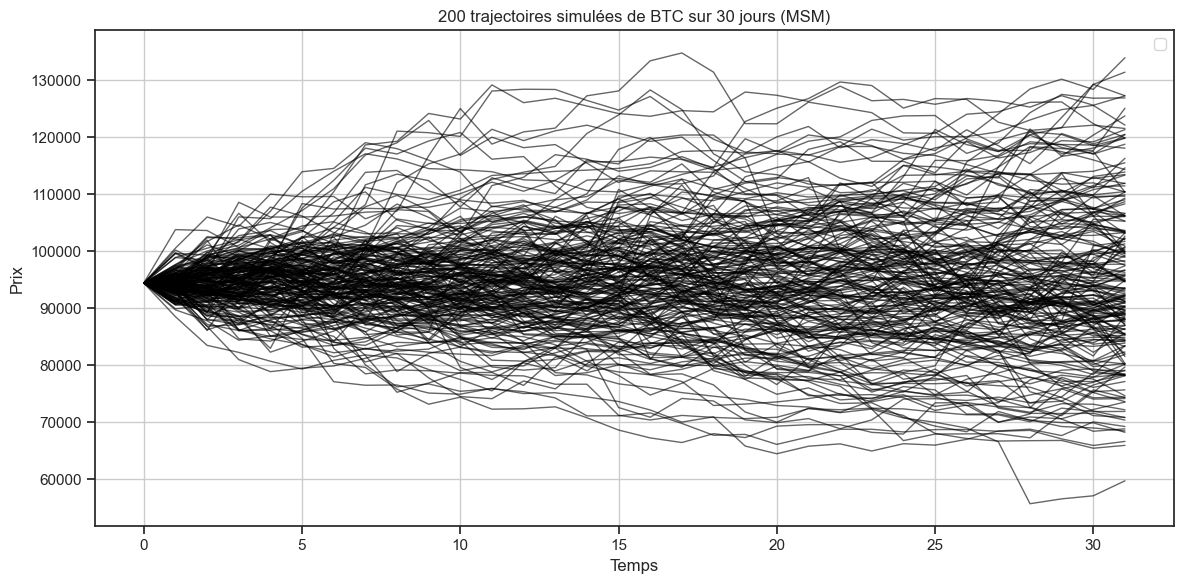

In [115]:
def compute_var(price_paths, percentile=5):
    return np.percentile(price_paths, percentile, axis=0)

def plot_paths_with_var(price_paths, var_path, num_paths_to_plot=200, percentile=5):
    T_plus_1 = price_paths.shape[1]
    time = np.arange(T_plus_1)

    # Sélectionner 20 trajectoires aléatoires
    selected_indices = np.random.choice(price_paths.shape[0], num_paths_to_plot, replace=False)
    selected_paths = price_paths[selected_indices]

    plt.figure(figsize=(12, 6))
    for path in selected_paths:
        plt.plot(time, path, color = 'black', alpha=0.6, linewidth=1)

    #plt.plot(time, var_path, color='red', label=f'VaR {percentile}%', linewidth=2)
    
    plt.xlabel("Temps")
    plt.ylabel("Prix")
    plt.legend()
    plt.title(f"{num_paths_to_plot} trajectoires simulées de BTC sur {T-1} jours (MSM)")
    plt.grid(True)
    plt.tight_layout()
    plt.show()


var_path = compute_var(simulation_p, percentile=5)
plot_paths_with_var(simulation_p, var_path, num_paths_to_plot=200, percentile=5)

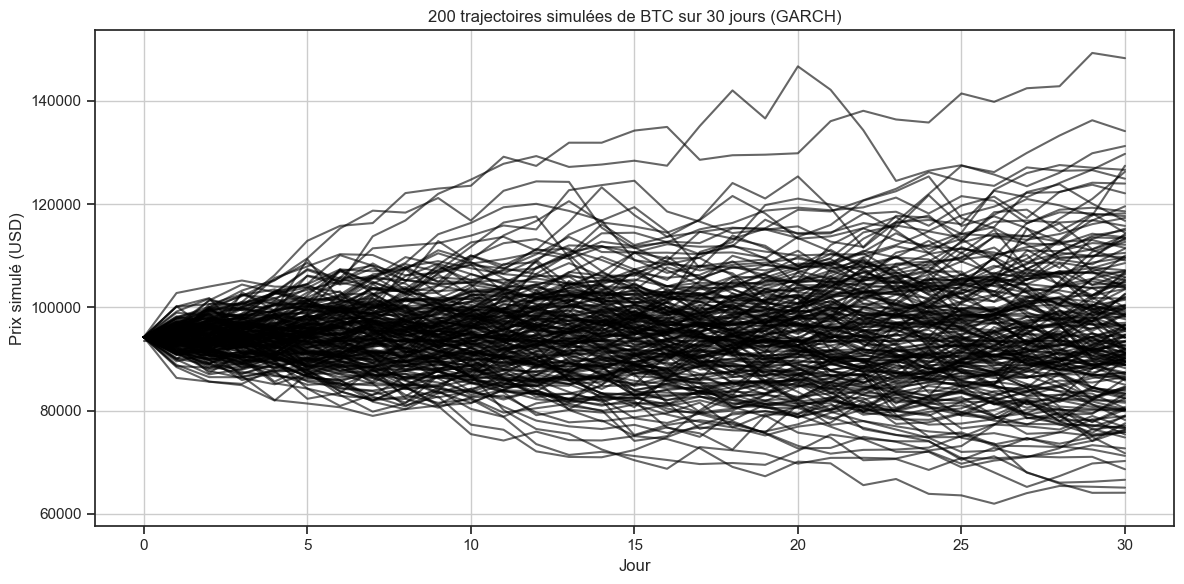

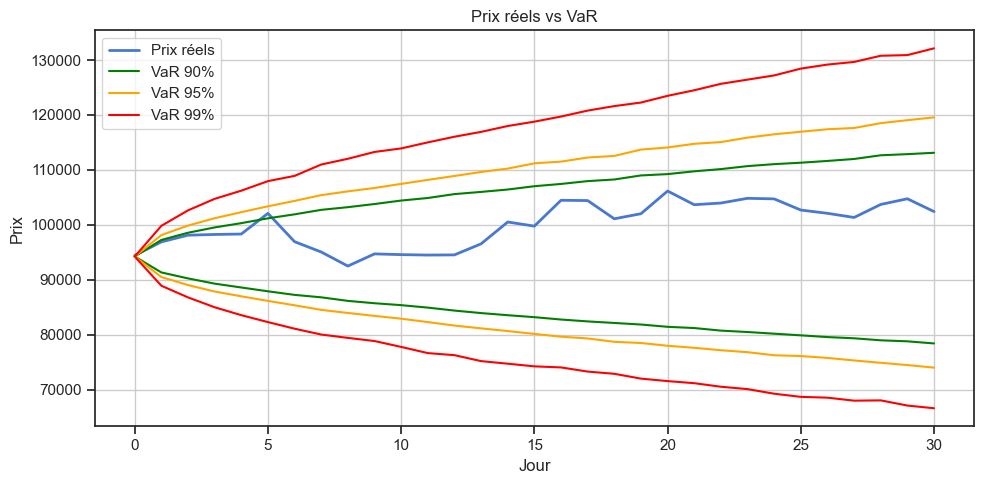

In [116]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from arch import arch_model

# === PARAMÈTRES ===
file_path = "BTC-USD.csv"
forecast_horizon = T    # Nombre de jours à prévoir
simulations = N         # Nombre de trajectoires simulées

# === CHARGEMENT ET TRAITEMENT DES DONNÉES ===
df = pd.read_csv(file_path)
df.columns = df.columns.str.strip()
df["Date"] = pd.to_datetime(df["Date"])
df = df.sort_values("Date")
df.set_index("Date", inplace=True)

df["Log_Ret"] = np.log(df["Price"] / df["Price"].shift(1))
df.dropna(inplace=True)

# === AJUSTEMENT DU MODÈLE GARCH(1,1) ===
returns = df["Log_Ret"]["2024-01-01":"2024-12-31"].copy() * 100 # ARCH attend des pourcentages
model = arch_model(returns, vol="Garch", p=1, q=1)
fit = model.fit(disp="off")

# === EXTRACTION DES PARAMÈTRES ===
params = fit.params
omega = params["omega"]
alpha = params["alpha[1]"]
beta = params["beta[1]"]

# === INITIALISATION POUR SIMULATIONS ===
last_vol = fit.conditional_volatility.iloc[-1]
last_return = returns.iloc[-1]

sim_logrets = np.zeros((forecast_horizon, simulations))
sim_prices = np.zeros((forecast_horizon, simulations))

# Dernier prix observé
last_price = df.loc["2024-12-31", "Price"]

for i in range(simulations):
    sim_prices[:, 0] = last_price
    sigma2 = last_vol ** 2
    r = last_return
    path = [r]  # on inclut le retour initial

    for t in range(1, forecast_horizon):
        z = np.random.normal()
        sigma2 = omega + alpha * (r**2) + beta * sigma2
        sigma = np.sqrt(sigma2)
        r = sigma * z
        path.append(r)
    
    sim_logrets[:, i] = np.array(path) / 100  # Retour à échelle normale
    sim_prices[:, i] = last_price * np.exp(np.cumsum(sim_logrets[:, i]))

# === AFFICHAGE DES TRAJECTOIRES SIMULÉES ===
plt.figure(figsize=(12, 6))
for i in range(200):
    plt.plot(sim_prices[:, i], alpha=0.6, color="black")
plt.title(f"200 trajectoires simulées de BTC sur {forecast_horizon-1} jours (GARCH)")
plt.xlabel("Jour")
plt.ylabel("Prix simulé (USD)")
plt.grid(True)
plt.tight_layout()
plt.show()

days = np.arange(forecast_horizon)

# Quantiles sur chaque ligne (i.e. pour chaque jour t)
var_90b = np.percentile(sim_prices, 10, axis=1)   # 90% VaR
var_90h = np.percentile(sim_prices, 90, axis=1)  
var_95b = np.percentile(sim_prices, 5, axis=1) # 95% VaR
var_95h = np.percentile(sim_prices, 95, axis=1)
var_99b = np.percentile(sim_prices, 1, axis=1)   # 99% VaR
var_99h = np.percentile(sim_prices, 99, axis=1)

# Moyenne des prix simulés
mean_prediction = np.mean(sim_prices, axis=1)

# (Optionnel) prix réels à comparer s’ils sont disponibles
real_prices = df["Price"].loc["2025-01-01":].values[:forecast_horizon]  # à ajuster

# === AFFICHAGE DES QUANTILES (Cône de VaR) ===
plt.figure(figsize=(10, 5))
plt.plot(real_prices, label="Prix réels", linewidth=2)
plt.plot(var_90b, label="VaR 90%", color="green")
plt.plot(var_95b, label="VaR 95%", color="orange")
plt.plot(var_99b, label="VaR 99%", color="red")
plt.plot(var_90h, color="green")
plt.plot(var_95h, color="orange")
plt.plot(var_99h, color="red")

plt.title("Prix réels vs VaR")
plt.xlabel("Jour")
plt.ylabel("Prix")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()





Rolling window 1 complete
Rolling window 2 complete
Rolling window 3 complete
Rolling window 4 complete
Rolling window 5 complete
Rolling window 6 complete
Rolling window 7 complete
Rolling window 8 complete
Rolling window 9 complete
Rolling window 10 complete
[0.02263243 0.02694484 0.02740538 0.02256658 0.02661818 0.0273416
 0.02285389 0.0268894  0.02763685 0.02290262 0.02712133 0.02791006
 0.02307108 0.02645052 0.02801856 0.02320289 0.02687951 0.02759651
 0.02288387 0.02727473 0.02726424 0.0235072  0.02722115 0.02763898
 0.02272967 0.02686141 0.02777815 0.0227046  0.02638524 0.02776162]


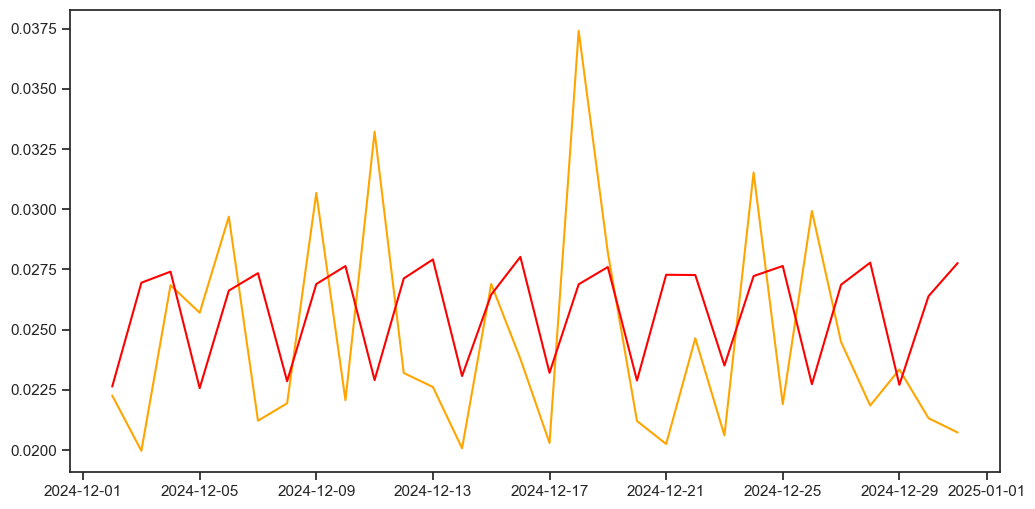

In [145]:
end_date = "2025-03-05"
last_month_hist_vol = historical_vol[-T:] 
last_month_exp_vol = ewma_vol[-T:] 
last_month_returns = df['Log_Ret'][-T:]    
last_month_index = last_month_hist_vol.index
last_month_fit_vol = msm_fit_volatility_tot[-T:]


def predict_MSM_roll(T, n_window):
    vol_predictions = []
    sigma_vect = []

    # Sécuriser les dates au format datetime
    local_start = pd.to_datetime(start_date)
    local_end = pd.to_datetime(end_date)

    for i in range(n_window):
        # Date de fin de la fenêtre courante
        current_end = local_end - pd.Timedelta(days=(n_window - i - 1) * T)

        # Extraire les données de la fenêtre
        ndf_train = df.loc[local_start : current_end]
        ndata = ndf_train['Log_Ret'].values[:, np.newaxis]
        ndata = ndata[1:]  # Supprimer le premier NA potentiel

        # Estimation de pi_t
        n_pi_t = g_pi_t(m_0, k_bar, ndata, [b, gamma_kbar, sigma])[-1, :]

        # Simulation Monte Carlo
        simulation_lr, vol_m = monte_carlo_markov(N, T, A, n_pi_t, m_0, k_bar, sigma)

        # Calcul de la volatilité prédite
        simulation_vol = np.std(simulation_lr, axis=0)
        sigma_arr = np.mean(vol_m, axis=0)

        # Stockage des résultats
        vol_predictions.append(simulation_vol)
        sigma_vect.extend(sigma_arr.tolist())

        print(f"Rolling window {i + 1} complete")

    # Aplatir les prédictions
    vol_predictions = np.concatenate(vol_predictions)

    return vol_predictions, sigma_vect
last_month_exp_vol_rolling, last_month_sigma_roll = predict_MSM_roll(3,10)
print(last_month_exp_vol_rolling)

plt.figure(figsize=(12, 6))
plt.plot(last_month_index, last_month_fit_vol, label="MSM Fit Volatility", color='orange')
plt.plot(last_month_index, last_month_exp_vol_rolling, color = "red")
plt.show()

In [128]:
# Calculate MAE between simulated volatility and historical volatility
print("Step 10: Calculating Mean Absolute Error (MAE)...")
mae = calculate_mae(historical_vol[-T:].values, simulation_vol)

# Plotting the results
print("Step 11: Plotting historical and simulated volatility...")
plt.figure(figsize=(12, 6))
# Seuil de VaR (10e percentile de la distribution normale standard)
#var_threshold = volatilite_arr * stats.norm.ppf(0.10)
var_threshold = simulation_vol * stats.norm.ppf(0.10)
logret_recent = df['Log_Ret'].iloc[-T:]
var_series = pd.Series(var_threshold, index=logret_recent.index)
indices_below = logret_recent[logret_recent < var_series].index
# Ajout des asymptotes verticales aux dates des violations de la VaR
for date in indices_below:
    plt.axvline(x=date, color='purple', linestyle='--', alpha=0.7, label="VaR violation" if date == indices_below[0] else "")
# Nombre d'instants où Log-Ret < volatilité estimée
print(f"pourcentage d'indices où Log-Ret < volatilité estimée : {len(indices_below)/T}")

# Plot historical volatility
plt.plot(historical_vol.index, historical_vol, label="Historical Volatility (30 days)", color='blue')
plt.plot(df_train.index, msm_fit_volatility, label="MSM Fit Volatility", color='yellow')
plt.plot(ewma_vol.index, ewma_vol, label="Historical EWMA Volatility", color='green')
plt.plot(df.index, msm_fit_volatility_tot, label="MSM Fit Volatility (total)", color='orange')
#print(historical_vol[-T+1:])
# Plot simulated volatility (average of simulations)
plt.plot(historical_vol.index[-T:], simulation_vol, label="Simulated Volatility (MSM)", color='red', linestyle='--')
plt.plot(historical_vol.index[-T:], volatilite_arr, label="volatility arr (MSM)", color='green', linestyle='--')


#print(simulated_vol)
# Adding labels and title
plt.title('Historical vs Simulated Volatility (MSM)')
plt.xlabel('Date')
plt.ylabel('Volatility')
plt.legend(loc="best")
plt.savefig("outofsample")
plt.show()

# Print MAE
print(f"Step 12: Mean Absolute Error (MAE) between Historical Volatility and Simulated Volatility: {mae}")

Step 10: Calculating Mean Absolute Error (MAE)...


ValueError: operands could not be broadcast together with shapes (30,) (31,) 

31 31


ValueError: x and y must have same first dimension, but have shapes (31,) and (15,)

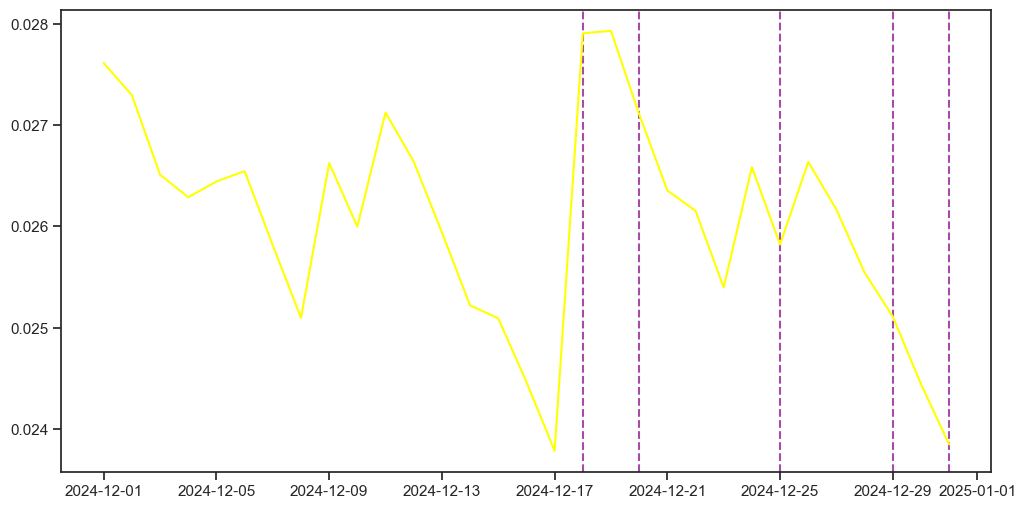

In [118]:
last_month_hist_vol = historical_vol[-T:] 
last_month_exp_vol = ewma_vol[-T:] 
last_month_returns = df['Log_Ret'][-T:]    
last_month_index = last_month_hist_vol.index
last_month_fit_vol = msm_fit_volatility_tot[-T:]

plt.figure(figsize=(12, 6))
print(len(volatilite_arr),len(last_month_returns))

# # VaR threshold pour chaque jour simulé
var_threshold = volatilite_arr * stats.norm.ppf(0.1)
indices_below = last_month_index[last_month_returns < var_threshold]

# Lignes verticales sur les violations de la VaR
for i, date in enumerate(indices_below):
    plt.axvline(x=date, color='purple', linestyle='--', alpha=0.7, label="VaR violation" if i == 0 else "")

# Plot: données historiques récentes
#plt.plot(last_month_index, last_month_hist_vol, label="Historical Volatility (30 days)", color='blue')
plt.plot(last_month_index, last_month_exp_vol, label="Exp Volatility (30 days)", color='yellow')
plt.plot(last_month_index, last_month_exp_vol_rolling, label="Exp Volatility Rolling window (30 days)", color='purple', linestyle='--')
plt.plot(last_month_index, last_month_sigma_roll, label="sigma roll", color='blue', linestyle='--') #le mauvais
plt.plot(last_month_index, last_month_fit_vol, label="MSM Fit Volatility", color='orange')
plt.plot(last_month_index, garch_vol_forecast, label="GARCH(1,1) Forecast Volatility", color='orange', linestyle='--')
plt.plot(last_month_index, simulation_vol, label="Simulated Volatility (MSM)", color='red', linestyle='--')
plt.plot(last_month_index, volatilite_arr, label="volatility arr (MSM)", color='green', linestyle='--')

plt.title("Last Month vs MSM Simulated Volatility")
plt.xlabel("Date")
plt.ylabel("Volatility")
plt.legend(loc="best")
plt.grid(True)
plt.tight_layout()
plt.savefig("outofsample_last_month")
plt.show()


In [ ]:
forecast_horizon = 30
forecast = garch_fit.forecast(horizon=forecast_horizon)

# Extract the forecasted volatility (which is the standard deviation, i.e., square root of variance)
forecasted_volatility = np.sqrt(forecast.variance.values[-1, :])

# Create a time index for the forecast period (e.g., next 30 days)
forecast_index = pd.date_range(start=data.index[-1], periods=forecast_horizon + 1, freq='B')[1:]  # Assuming business days


AttributeError: 'numpy.ndarray' object has no attribute 'index'